# 1. Input Series Exploratory Data Analysis

In [11]:
import pandas as pd
from pathlib import Path

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

INPUT_FILE = PROJECT_ROOT / "data" / "raw" / "eingangsbandwaage_studenten.csv"
MATERIAL_FILE = PROJECT_ROOT / "data" / "raw" / "ballengewichte_studenten.csv"
HOLIDAY_FILE = PROJECT_ROOT / "data" / "processed" / "public_holidays.csv"

FIGURE_DIR = PROJECT_ROOT / "outputs" / "eda" / "figures"
TABLE_DIR = PROJECT_ROOT / "outputs" / "eda" / "tables"

print("Input File:", PROJECT_ROOT)

Input File: D:\TU_DataScience\22_Data Mining Cup\TS-Forecasting-Project


### Data structure, date coverage and quality

In [7]:
# Data structure, date coverage and quality

df = pd.read_csv(INPUT_FILE)

df["Date"] = pd.to_datetime(df["Zeitstempel"])
df = df.sort_values("Date")

print("Rows:", len(df))
print("Date range:", df["Date"].min(), "to", df["Date"].max())

print("Duplicate dates:", df["Date"].duplicated().sum())

print("Missing Input:", df["Masse"].isna().sum())
print("Zero Input:", (df["Masse"] == 0).sum())
print("Negative Input:", (df["Masse"] < 0).sum())

full_dates = pd.date_range(
    start=df["Date"].min(),
    end=df["Date"].max(),
    freq="D",
)

missing_dates = full_dates.difference(df["Date"])

print("Missing calendar dates:", len(missing_dates))

Rows: 1896
Date range: 2019-10-24 00:00:00 to 2024-12-31 00:00:00
Duplicate dates: 0
Missing Input: 0
Zero Input: 248
Negative Input: 4
Missing calendar dates: 0


### Inspect negative Input values

In [8]:
# Check day of negative Input values

negative_input = df[df["Masse"] < 0].copy()

negative_input["day_of_week"] = negative_input["Date"].dt.dayofweek
negative_input["is_weekend"] = negative_input["day_of_week"] >= 5

print("Negative Input count:", len(negative_input))
print()
print("Weekend negatives:", negative_input["is_weekend"].sum())
print("Weekday negatives:", (~negative_input["is_weekend"]).sum())

print("\nNegative values by weekday:")
print(
    negative_input["Date"]
    .dt.day_name()
    .value_counts()
    .sort_index()
)


# Check whether negative Input values occur on public holidays
holidays = pd.read_csv(HOLIDAY_FILE)
holidays["Date"] = pd.to_datetime(holidays["Date"])

negative_input = negative_input.merge(
    holidays[["Date", "holiday_name", "is_holiday"]],
    left_on="Date",
    right_on="Date",
    how="left",
)

# Dates not found in the holiday table are treated as non-holidays
negative_input["is_holiday"] = (
    negative_input["is_holiday"]
    .fillna(0)
    .astype(int)
)

print("\nNegative Input count:", len(negative_input))
print("On public holidays:", negative_input["is_holiday"].sum())
print("Not on public holidays:", (negative_input["is_holiday"] == 0).sum())

print("\nBreakdown:")
print(
    negative_input
    .groupby(["is_weekend", "is_holiday"])
    .size()
)

Negative Input count: 4

Weekend negatives: 2
Weekday negatives: 2

Negative values by weekday:
Date
Monday     1
Sunday     2
Tuesday    1
Name: count, dtype: int64

Negative Input count: 4
On public holidays: 1
Not on public holidays: 3

Breakdown:
is_weekend  is_holiday
False       0             1
            1             1
True        0             2
dtype: int64


### Inspect zero Input values

In [9]:
# Inspect zero Input values

zero_input = df[df["Masse"] == 0].copy()

zero_input["day_of_week"] = zero_input["Date"].dt.dayofweek
zero_input["is_weekend"] = zero_input["day_of_week"] >= 5

# Add public-holiday information
zero_input = zero_input.merge(
    holidays[["Date", "is_holiday"]],
    left_on="Date"
            "",
    right_on="Date",
    how="left",
)

zero_input["is_holiday"] = (
    zero_input["is_holiday"]
    .fillna(0)
    .astype(int)
)

print("Zero Input count:", len(zero_input))

print("\nWeekend / weekday:")
print("Weekend zeros:", zero_input["is_weekend"].sum())
print("Weekday zeros:", (~zero_input["is_weekend"]).sum())

print("\nPublic holidays:")
print("Holiday zeros:", zero_input["is_holiday"].sum())
print("Non-holiday zeros:", (zero_input["is_holiday"] == 0).sum())

print("\nBreakdown:")
print(
    zero_input
    .groupby(["is_weekend", "is_holiday"])
    .size())

# Consecutive zero Input blocks
is_zero = df["Masse"].eq(0)

# Each change between zero/non-zero starts a new group
block_id = is_zero.ne(is_zero.shift()).cumsum()

zero_blocks = (
    df.loc[is_zero, ["Date"]]
    .assign(block_id=block_id[is_zero])
    .groupby("block_id")
    .agg(
        start_date=("Date", "min"),
        end_date=("Date", "max"),
        length=("Date", "size"),
    )
    .reset_index(drop=True)
)

print("Number of zero blocks:", len(zero_blocks))

print("\nZero-block length distribution:")
print(
    zero_blocks["length"]
    .value_counts()
    .sort_index()
)

print("\nLongest zero blocks:")
print(
    zero_blocks[["length"]]
    .sort_values("length", ascending=False)
    .head(10)
    .to_string(index=False)
)

print("\nZero blocks longer than 5 days:")
print((zero_blocks["length"] > 5).sum())

print(
    "Zero observations inside blocks longer than 5 days:",
    zero_blocks.loc[
        zero_blocks["length"] > 5,
        "length"
    ].sum()
)

long_zero_blocks = (
    zero_blocks[zero_blocks["length"] > 5]
    .sort_values("length", ascending=False)
)

display(long_zero_blocks)


Zero Input count: 248

Weekend / weekday:
Weekend zeros: 165
Weekday zeros: 83

Public holidays:
Holiday zeros: 19
Non-holiday zeros: 229

Breakdown:
is_weekend  is_holiday
False       0              71
            1              12
True        0             158
            1               7
dtype: int64
Number of zero blocks: 140

Zero-block length distribution:
length
1     119
2      13
3       4
5       1
6       1
7       1
73      1
Name: count, dtype: int64

Longest zero blocks:
 length
     73
      7
      6
      5
      3
      3
      3
      3
      2
      2

Zero blocks longer than 5 days:
3
Zero observations inside blocks longer than 5 days: 86


,start_date,end_date,length
106,2023-05-16,2023-07-27,73
124,2023-12-07,2023-12-13,7
137,2024-10-25,2024-10-30,6


### Plot zero values

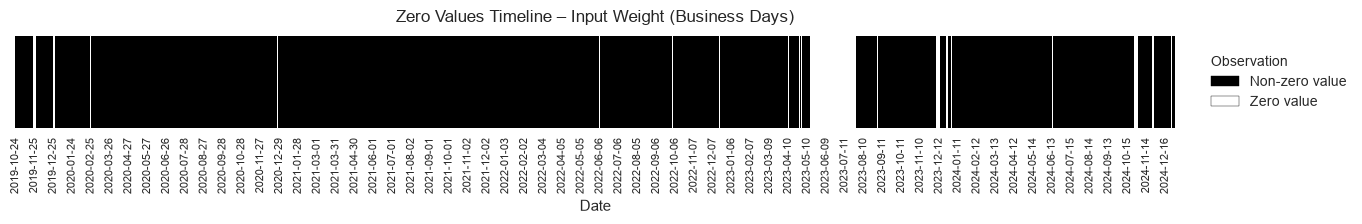

In [12]:
# Zero values timeline
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

# Business days
df_business = (
    df[df["Date"].dt.dayofweek < 5]
    .copy()
    .sort_values("Date")
    .reset_index(drop=True)
)

data_present = df_business["Masse"].ne(0)

labels = df_business["Date"].dt.strftime("%Y-%m-%d")

fig, ax = plt.subplots(figsize=(16, 2.5))

sns.heatmap(
    data_present.to_frame().T,
    cbar=False,
    cmap=["white", "black"],
    yticklabels=False,
    ax=ax
)

step = 22

ticks = list(range(0, len(labels), step))
tick_labels = labels.iloc[::step]

ax.set_xticks(ticks)
ax.set_xticklabels(
    tick_labels,
    rotation=90,
    fontsize=8
)

ax.set_title(
    "Zero Values Timeline – Input Weight (Business Days)",
    fontsize=12,
    pad=10
)

ax.set_xlabel("Date")
ax.set_ylabel("")

legend_elements = [
    Patch(
        facecolor="black",
        edgecolor="black",
        label="Non-zero value"
    ),
    Patch(
        facecolor="white",
        edgecolor="black",
        label="Zero value"
    ),
]

legend = ax.legend(
    handles=legend_elements,
    title="Observation",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    ncol=1,
    frameon=False
)

legend.get_title().set_ha("left")
legend._legend_box.align = "left"

plt.subplots_adjust(
    right=0.85,
    bottom=0.45,
    top=0.82
)

fig.savefig(
    FIGURE_DIR / "input_zero_values_timeline.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

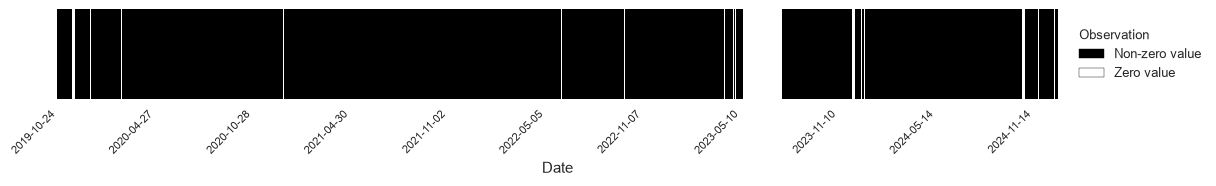

In [16]:
# Zero values timeline -- report version
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

# Business days
df_business = (
    df[df["Date"].dt.dayofweek < 5]
    .copy()
    .sort_values("Date")
    .reset_index(drop=True)
)

# True = non-zero Input
# False = zero Input
data_present = df_business["Masse"].ne(0)

labels = df_business["Date"].dt.strftime("%Y-%m-%d")

fig, ax = plt.subplots(figsize=(14, 1.8))

sns.heatmap(
    data_present.to_frame().T,
    cbar=False,
    cmap=["white", "black"],
    yticklabels=False,
    ax=ax
)

# Approximately one tick every six months
step = 132

ticks = list(range(0, len(labels), step))
tick_labels = labels.iloc[::step]

ax.set_xticks(ticks)
ax.set_xticklabels(
    tick_labels,
    rotation=45,
    ha="right",
    fontsize=8
)

ax.set_xlabel("Date")
ax.set_ylabel("")

legend_elements = [
    Patch(
        facecolor="black",
        edgecolor="black",
        label="Non-zero value"
    ),
    Patch(
        facecolor="white",
        edgecolor="black",
        label="Zero value"
    ),
]

legend = ax.legend(
    handles=legend_elements,
    title="Observation",
    loc="center left",
    bbox_to_anchor=(1.01, 0.5),
    frameon=False,
    fontsize=9
)

legend.get_title().set_fontsize(9)
legend.get_title().set_ha("left")
legend._legend_box.align = "left"

plt.subplots_adjust(
    right=0.84,
    bottom=0.38
)

fig.savefig(
    FIGURE_DIR / "input_zero_values_timeline_r.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 2. Material Series Exploratory Data Analysis

In [18]:
# Data structure, date coverage, quality and integrity

MATERIAL_FILE = (PROJECT_ROOT/"data"/"raw"/"ballengewichte_studenten.csv")

df_material = pd.read_csv(MATERIAL_FILE)

df_material["Date"] = pd.to_datetime(df_material["Datum"])
df_material = df_material.sort_values("Date")

print("Rows:", len(df_material))
print(
    "Date range:",
    df_material["Date"].min(),
    "to",
    df_material["Date"].max()
)
print(
    "Duplicate dates:",
    df_material["Date"].duplicated().sum()
)

full_dates = pd.date_range(
    start=df_material["Date"].min(),
    end=df_material["Date"].max(),
    freq="D",
)

missing_dates = full_dates.difference(df_material["Date"])

print("Missing calendar dates:", len(missing_dates))

Rows: 1546
Date range: 2020-03-02 00:00:00 to 2024-12-31 00:00:00
Duplicate dates: 0
Missing calendar dates: 220


### Inspect missing dates

In [19]:
# Inspect missing dates

missing_dates_df = pd.DataFrame({
    "Date": missing_dates
})

missing_dates_df["day_of_week"] = (
    missing_dates_df["Date"].dt.day_name()
)

missing_dates_df["is_weekend"] = (
    missing_dates_df["Date"].dt.dayofweek >= 5
)

print("Missing calendar dates:", len(missing_dates_df))

print(
    "Missing weekend dates:",
    missing_dates_df["is_weekend"].sum()
)

print(
    "Missing weekday dates:",
    (~missing_dates_df["is_weekend"]).sum()
)

print("\nMissing dates by weekday:")
print(
    missing_dates_df["day_of_week"]
    .value_counts()
    .reindex([
        "Monday",
        "Tuesday",
        "Wednesday",
        "Thursday",
        "Friday",
        "Saturday",
        "Sunday",
    ])
)

# Public holidays among missing weekday dates
missing_dates_df = missing_dates_df.merge(
    holidays[["Date", "is_holiday"]],
    on="Date",
    how="left",
)

missing_dates_df["is_holiday"] = (
    missing_dates_df["is_holiday"]
    .fillna(0)
    .astype(int)
)

missing_weekdays = missing_dates_df[
    ~missing_dates_df["is_weekend"]
].copy()

print("Missing weekday dates:", len(missing_weekdays))

print(
    "Missing weekdays on public holidays:",
    missing_weekdays["is_holiday"].sum()
)

print(
    "Missing weekdays on non-holidays:",
    (missing_weekdays["is_holiday"] == 0).sum()
)

Missing calendar dates: 220
Missing weekend dates: 160
Missing weekday dates: 60

Missing dates by weekday:
day_of_week
Monday        21
Tuesday       13
Wednesday      9
Thursday       8
Friday         9
Saturday      27
Sunday       133
Name: count, dtype: int64
Missing weekday dates: 60
Missing weekdays on public holidays: 11
Missing weekdays on non-holidays: 49


### Missing Values for each Material

In [20]:
# Missing values for each Material

material_cols = [str(i) for i in range(1, 14)]

missing_summary = pd.DataFrame({
    "missing_count": df_material[material_cols].isna().sum(),
    "missing_percent": (
        df_material[material_cols].isna().mean() * 100
    )
})

missing_summary.index.name = "Material"

print(missing_summary.round(2))

# Number of missing materials in each existing row
df_material["n_missing_materials"] = (
    df_material[material_cols]
    .isna()
    .sum(axis=1)
)

print("Rows with at least one missing Material:",
      (df_material["n_missing_materials"] > 0).sum())

print("Rows with all 13 Materials missing:",
      (df_material["n_missing_materials"] == 13).sum())

print("Rows with partially missing Materials:",
      (
          (df_material["n_missing_materials"] > 0)
          & (df_material["n_missing_materials"] < 13)
      ).sum()
)

print("\nDistribution of number of missing Materials per row:")

print(
    df_material["n_missing_materials"]
    .value_counts()
    .sort_index()
)


          missing_count  missing_percent
Material                                
1                     0              0.0
2                     0              0.0
3                     0              0.0
4                     0              0.0
5                     0              0.0
6                     0              0.0
7                     0              0.0
8                     0              0.0
9                     0              0.0
10                    0              0.0
11                    0              0.0
12                    0              0.0
13                    0              0.0
Rows with at least one missing Material: 0
Rows with all 13 Materials missing: 0
Rows with partially missing Materials: 0

Distribution of number of missing Materials per row:
n_missing_materials
0    1546
Name: count, dtype: int64


### Zero and negative values in Material Fractions

In [21]:
# Zero and negative values in Material Fractions

value_quality_summary = pd.DataFrame({
    "negative_count": (df_material[material_cols] < 0).sum(),
    "zero_count": (df_material[material_cols] == 0).sum(),
})

value_quality_summary.index.name = "Material"

print(value_quality_summary)

# Number of zero-valued materials per date
df_material["n_zero_materials"] = (
    df_material[material_cols]
    .eq(0)
    .sum(axis=1)
)

print(
    "Rows with at least one zero Material:",
    (df_material["n_zero_materials"] > 0).sum()
)

print(
    "Rows with all 13 Materials equal to zero:",
    (df_material["n_zero_materials"] == 13).sum()
)

print(
    "Rows with some, but not all, Materials equal to zero:",
    (
        (df_material["n_zero_materials"] > 0)
        & (df_material["n_zero_materials"] < 13)
    ).sum()
)

print("\nDistribution of number of zero Materials per row:")
print(
    df_material["n_zero_materials"]
    .value_counts()
    .sort_index()
)

          negative_count  zero_count
Material                            
1                      0          35
2                      0          70
3                      0          91
4                      0         108
5                      0          31
6                      0          80
7                      0         149
8                      0          70
9                      0          70
10                     0          41
11                     0          86
12                     0         758
13                     0         864
Rows with at least one zero Material: 1202
Rows with all 13 Materials equal to zero: 0
Rows with some, but not all, Materials equal to zero: 1202

Distribution of number of zero Materials per row:
n_zero_materials
0     344
1     714
2     325
3      29
4      15
5      14
6      23
7      14
8      26
9      15
10     13
11      5
12      9
Name: count, dtype: int64


### Sum of Material fractions

In [22]:
# Sum of Material Fractions

df_material["material_sum"] = (
    df_material[material_cols]
    .sum(axis=1)
)

print(df_material["material_sum"].describe())

print(
    "\nRows with material_sum == 0:",
    df_material["material_sum"].eq(0).sum()
)

print(
    "Rows with material_sum < 0:",
    df_material["material_sum"].lt(0).sum()
)

count    1.546000e+03
mean     1.000000e+00
std      2.316458e-16
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
Name: material_sum, dtype: float64

Rows with material_sum == 0: 0
Rows with material_sum < 0: 0


### Plot for missing values, Material importance

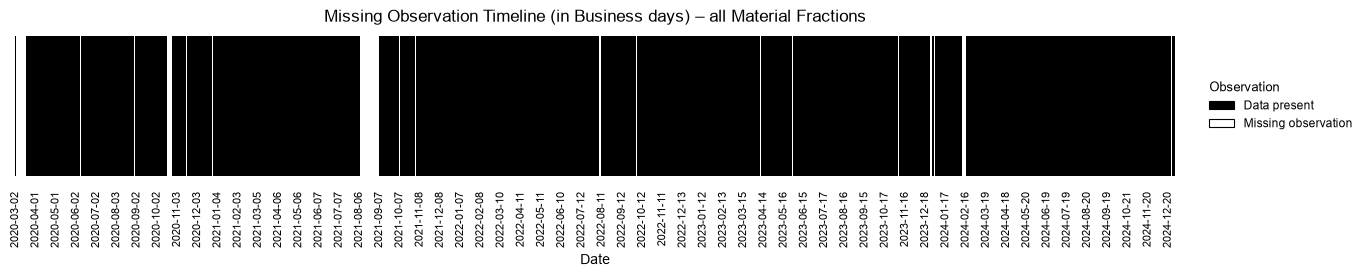

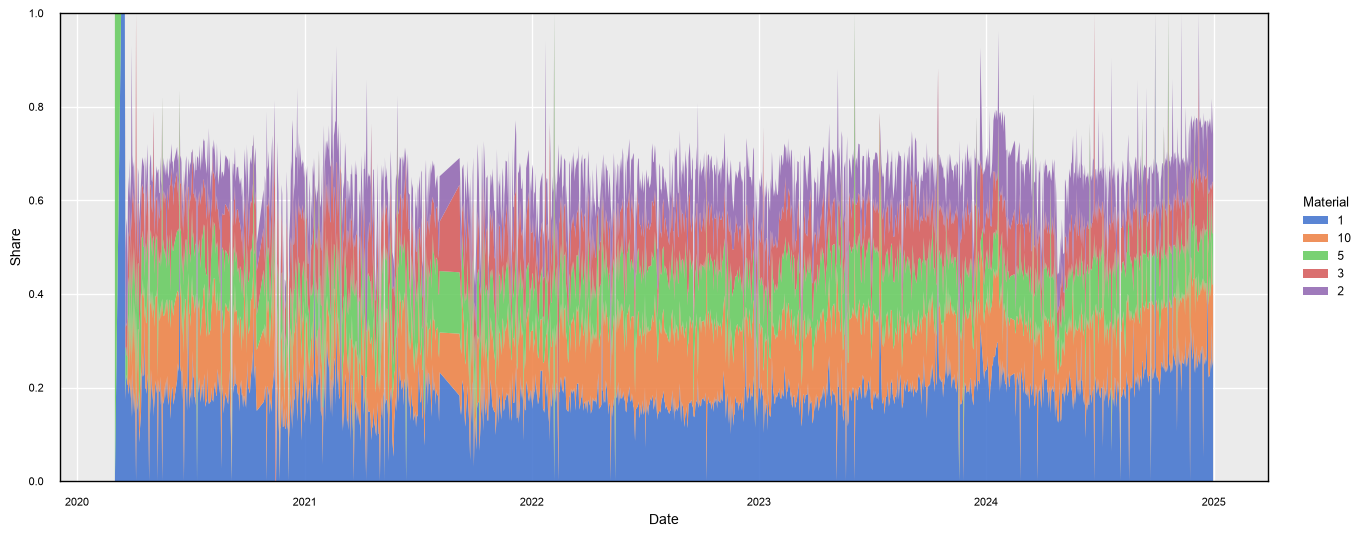

In [25]:
# Plot for missing values, Material importance

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

sns.set_theme(
    style="whitegrid",
    context="paper"
)

plt.rcParams.update({
    "figure.figsize": (16, 3),
    "axes.facecolor": "#EBEBEB",
    "figure.facecolor": "white",
    "axes.edgecolor": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "text.color": "black",
    "grid.color": "white",
    "grid.linewidth": 1.0,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
})

# Missing dates timeline - Material Fractions
material_cols = [str(i) for i in range(1, 14)]

# Keep only date + material columns
df_fraction_aligned = df_material[
    ["Date"] + material_cols
].copy()

df_fraction_aligned = (
    df_fraction_aligned
    .set_index("Date")
    .sort_index()
)

# Complete business-day timeline
business_days = pd.date_range(
    start=df_fraction_aligned.index.min(),
    end=df_fraction_aligned.index.max(),
    freq="B"
)

df_fraction_aligned = df_fraction_aligned.reindex(business_days)

# One material is sufficient because missing dates affect all materials
reference_material = "1"

# True = data exists, False = missing
data_present = df_fraction_aligned[reference_material].notna()

labels = df_fraction_aligned.index.strftime("%Y-%m-%d")

fig, ax = plt.subplots(figsize=(16, 2.8))

sns.heatmap(
    data_present.to_frame().T,
    cbar=False,
    cmap=["white", "black"],
    yticklabels=False,
    ax=ax
)

# Date labels every 22 business days (~1 month)
step = 22
ticks = range(0, len(labels), step)
tick_labels = labels[::step]

ax.set_xticks(ticks)
ax.set_xticklabels(
    tick_labels,
    rotation=90,
    fontsize=8
)

ax.set_title(
    "Missing Observation Timeline (in Business days) – all Material Fractions",
    pad=10
)

ax.set_xlabel("Date")
ax.set_ylabel("")

legend_elements = [
    Patch(
        facecolor="black",
        edgecolor="black",
        label="Data present"
    ),
    Patch(
        facecolor="white",
        edgecolor="black",
        label="Missing observation"
    ),
]

legend = ax.legend(
    handles=legend_elements,
    title="Observation",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    ncol=1,
    frameon=False
)
legend.get_title().set_ha("left")
legend._legend_box.align = "left"

plt.subplots_adjust(
    right=0.85,
    bottom=0.35,
    top=0.85
)

plt.show()

fig.savefig(
    FIGURE_DIR / "materials_missing_timeline.png",
    dpi=300,
    bbox_inches="tight"
)

# Top 5 Material Composition Over Time
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

top5_materials = (
    df_material[material_cols]
    .mean()
    .sort_values(ascending=False)
    .head(5)
    .index
    .tolist()
)

plot_df = (
    df_material[["Date"] + top5_materials]
    .copy()
    .sort_values("Date")
)

colors = sns.color_palette("muted", n_colors=5)

fig, ax = plt.subplots(figsize=(16, 6))

ax.stackplot(
    plot_df["Date"],
    *[plot_df[col] for col in top5_materials],
    labels=top5_materials,
    colors=colors,
    alpha=0.9,
    edgecolor="none",
    linewidth=0
)

ax.set_facecolor("#EBEBEB")
fig.patch.set_facecolor("white")

ax.grid(
    True,
    color="white",
    linewidth=1.0
)

ax.set_axisbelow(True)

# ax.set_title(
#     "Top 5 Material Composition Over Time",
#     fontsize=13,
#     pad=12
# )

ax.set_xlabel("Date", fontsize=10)
ax.set_ylabel("Share", fontsize=10)

ax.set_ylim(0, 1)

ax.xaxis.set_major_locator(
    mdates.YearLocator()
)

ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%Y")
)

ax.tick_params(
    axis="x",
    labelrotation=0
)

legend = ax.legend(
    title="Material",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    ncol=1,
    frameon=False
)
legend.get_title().set_ha("left")
legend._legend_box.align = "left"

plt.subplots_adjust(
    right=0.88,
    top=0.90,
    bottom=0.12
)

plt.show()

fig.savefig(
    FIGURE_DIR / "top5_material_fractions_over_time.png",
    dpi=300,
    bbox_inches="tight"
)

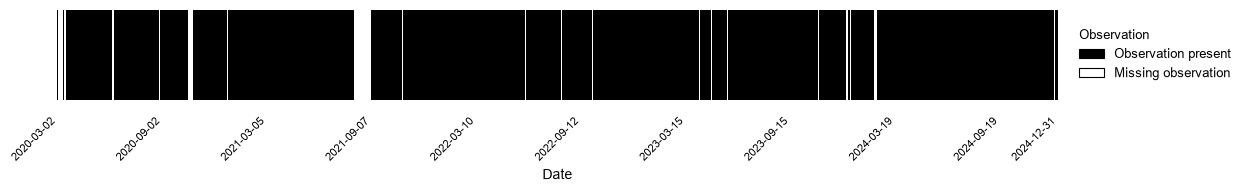

In [24]:
# Missing observation timeline -- report version
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

sns.set_theme(
    style="whitegrid",
    context="paper"
)

plt.rcParams.update({
    "figure.figsize": (14, 2.2),
    "axes.facecolor": "#EBEBEB",
    "figure.facecolor": "white",
    "axes.edgecolor": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "text.color": "black",
    "grid.color": "white",
    "grid.linewidth": 1.0,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
})

material_cols = [str(i) for i in range(1, 14)]

# Keep only date + material columns
df_fraction_aligned = df_material[["Date"] + material_cols].copy()

df_fraction_aligned = (
    df_fraction_aligned
    .set_index("Date")
    .sort_index()
)

# Complete business-day timeline
business_days = pd.date_range(
    start=df_fraction_aligned.index.min(),
    end=df_fraction_aligned.index.max(),
    freq="B"
)

df_fraction_aligned = df_fraction_aligned.reindex(business_days)

# One material is enough because missing dates affect all materials equally
reference_material = "1"

# True = data exists, False = missing
data_present = df_fraction_aligned[reference_material].notna()

labels = df_fraction_aligned.index.strftime("%Y-%m-%d")

fig, ax = plt.subplots(figsize=(14, 1.8))

sns.heatmap(
    data_present.to_frame().T,
    cbar=False,
    cmap=["white", "black"],
    yticklabels=False,
    ax=ax
)

# Fewer date labels for report readability
# approx. every 6 months in business days
step = 132
ticks = list(range(0, len(labels), step))
tick_labels = labels[::step]

# make sure the last date is also shown
if ticks[-1] != len(labels) - 1:
    ticks.append(len(labels) - 1)
    tick_labels = list(tick_labels) + [labels[-1]]

ax.set_xticks(ticks)
ax.set_xticklabels(
    tick_labels,
    rotation=45,
    ha="right",
    fontsize=8
)

ax.set_xlabel("Date")
ax.set_ylabel("")

legend_elements = [
    Patch(
        facecolor="black",
        edgecolor="black",
        label="Observation present"
    ),
    Patch(
        facecolor="white",
        edgecolor="black",
        label="Missing observation"
    ),
]

legend = ax.legend(
    handles=legend_elements,
    title="Observation",
    loc="center left",
    bbox_to_anchor=(1.01, 0.5),
    frameon=False,
    fontsize=9
)

legend.get_title().set_fontsize(9)
legend.get_title().set_ha("left")
legend._legend_box.align = "left"

plt.subplots_adjust(
    right=0.84,
    bottom=0.38
)

fig.savefig(
    FIGURE_DIR / "materials_missing_timeline_r.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

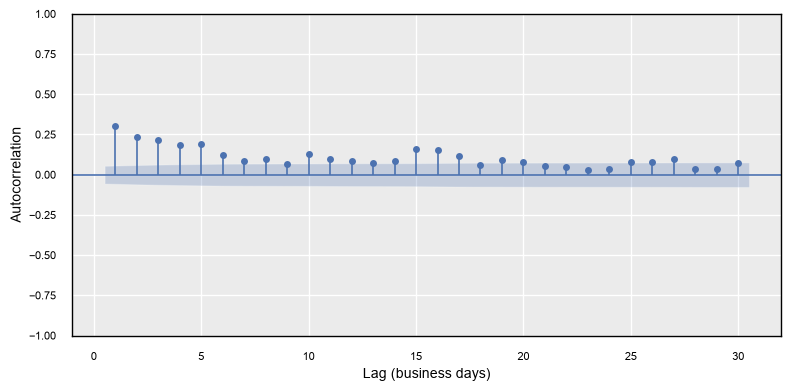

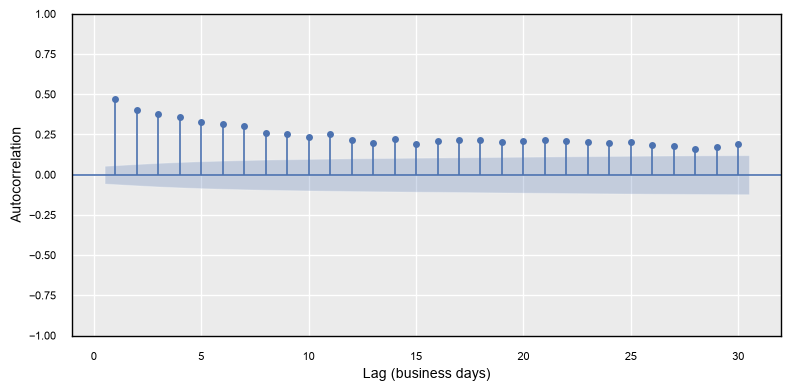

In [28]:
# ACF comparison, material 7

import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

# ---------------------------------------------------------
# Prepare business-day aligned material data
# ---------------------------------------------------------

material_cols = [str(i) for i in range(1, 14)]

df_acf = (
    df_material[["Date"] + material_cols]
    .copy()
    .set_index("Date")
    .sort_index()
)

# Complete business-day calendar
business_days = pd.date_range(
    start=df_acf.index.min(),
    end=df_acf.index.max(),
    freq="B"
)

df_acf = df_acf.reindex(business_days)

# ---------------------------------------------------------
# Materials selected for illustration
# Material 7  -> seasonal
# Material 2  -> non-seasonal
# ---------------------------------------------------------

seasonal_material = "7"
nonseasonal_material = "2"

# Linear interpolation, consistent with the final
# ARIMA/SARIMA model-selection setup
y_seasonal = (
    df_acf[seasonal_material]
    .astype(float)
    .interpolate(
        method="linear",
        limit_area="inside"
    )
    .dropna()
)

y_nonseasonal = (
    df_acf[nonseasonal_material]
    .astype(float)
    .interpolate(
        method="linear",
        limit_area="inside"
    )
    .dropna()
)

fig, ax = plt.subplots(figsize=(8, 4))

plot_acf(
    y_seasonal,
    lags=30,
    zero=False,
    ax=ax
)

ax.set_title("")
ax.set_xlabel("Lag (business days)")
ax.set_ylabel("Autocorrelation")

fig.tight_layout()

fig.savefig(
    FIGURE_DIR / "acf_material_7.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

fig, ax = plt.subplots(figsize=(8, 4))

plot_acf(
    y_nonseasonal,
    lags=30,
    zero=False,
    ax=ax
)
ax.set_title("")
ax.set_xlabel("Lag (business days)")
ax.set_ylabel("Autocorrelation")

fig.tight_layout()

fig.savefig(
    FIGURE_DIR / "acf_material_2.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [29]:
# Input vs. Material Fractions
# Pearson Correlation + Mutual Information
# No interpolation

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_regression


# ---------------------------------------------------------
# 1. Prepare Input data
# ---------------------------------------------------------

df_input_mi = (
    df[["Date", "Masse"]]
    .copy()
    .sort_values("Date")
    .reset_index(drop=True)
)

df_input_mi["Date"] = pd.to_datetime(df_input_mi["Date"])
df_input_mi["Masse"] = df_input_mi["Masse"].astype(float)


# ---------------------------------------------------------
# 2. Apply already-defined Input validity rules
#    No interpolation is performed
# ---------------------------------------------------------

# Negative Input values are invalid
df_input_mi.loc[
    df_input_mi["Masse"] < 0,
    "Masse"
] = np.nan


# Detect consecutive zero blocks on the ORIGINAL daily calendar
zero_mask = df_input_mi["Masse"].eq(0)

zero_group = zero_mask.ne(zero_mask.shift()).cumsum()

zero_block_length = (
    zero_mask
    .groupby(zero_group)
    .transform("sum")
)

# Zero blocks longer than 5 calendar days are considered abnormal
long_zero_block = zero_mask & (zero_block_length > 5)

df_input_mi.loc[
    long_zero_block,
    "Masse"
] = np.nan


# ---------------------------------------------------------
# 3. Restrict Input to business days
# ---------------------------------------------------------

df_input_mi = (
    df_input_mi[
        df_input_mi["Date"].dt.dayofweek < 5
    ]
    .copy()
)


# ---------------------------------------------------------
# 4. Prepare Material data
# ---------------------------------------------------------

material_cols = [str(i) for i in range(1, 14)]

df_material_mi = (
    df_material[["Date"] + material_cols]
    .copy()
    .sort_values("Date")
)

df_material_mi["Date"] = pd.to_datetime(
    df_material_mi["Date"]
)

# Business days only
df_material_mi = (
    df_material_mi[
        df_material_mi["Date"].dt.dayofweek < 5
    ]
    .copy()
)


# ---------------------------------------------------------
# 5. Merge Input and Material observations
# ---------------------------------------------------------
# Inner merge:
# Only dates with an actually observed material row are retained.
#
# Missing / abnormal Input values remain NaN and are removed
# separately for each calculation.
# ---------------------------------------------------------

df_input_material = pd.merge(
    df_material_mi,
    df_input_mi,
    on="Date",
    how="inner"
)

print("Common business-day observations:",
      len(df_input_material))


# ---------------------------------------------------------
# 6. Pearson correlation and Mutual Information
# ---------------------------------------------------------

results = []

for material in material_cols:

    temp = (
        df_input_material[
            ["Masse", material]
        ]
        .dropna()
        .copy()
    )

    x = temp["Masse"].astype(float)
    y = temp[material].astype(float)

    # Pearson correlation
    pearson_r = x.corr(
        y,
        method="pearson"
    )

    # Mutual Information
    mi = mutual_info_regression(
        X=x.to_numpy().reshape(-1, 1),
        y=y.to_numpy(),
        discrete_features=False,
        random_state=42
    )[0]

    results.append({
        "Material": material,
        "Pearson_r": pearson_r,
        "Abs_Pearson_r": abs(pearson_r),
        "Mutual_Information": mi,
        "N": len(temp)
    })


input_material_dependence = pd.DataFrame(results)

print(
    input_material_dependence.round(4)
)

Common business-day observations: 1202
   Material  Pearson_r  Abs_Pearson_r  Mutual_Information     N
0         1     0.1569         0.1569              0.0811  1140
1         2     0.0048         0.0048              0.0328  1140
2         3     0.0427         0.0427              0.0899  1140
3         4    -0.0359         0.0359              0.0470  1140
4         5    -0.0449         0.0449              0.0219  1140
5         6     0.0824         0.0824              0.0147  1140
6         7     0.0259         0.0259              0.0218  1140
7         8    -0.0468         0.0468              0.0190  1140
8         9    -0.0253         0.0253              0.0146  1140
9        10     0.0403         0.0403              0.0222  1140
10       11     0.0169         0.0169              0.0540  1140
11       12     0.0297         0.0297              0.0000  1140
12       13    -0.1190         0.1190              0.0218  1140


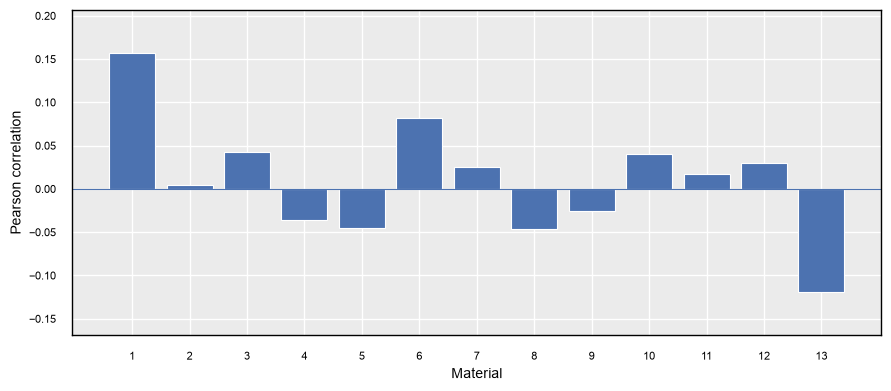

In [30]:
fig, ax = plt.subplots(figsize=(9, 4))

ax.bar(
    input_material_dependence["Material"],
    input_material_dependence["Pearson_r"]
)

ax.axhline(
    0,
    linewidth=0.8
)

ax.set_xlabel("Material")
ax.set_ylabel("Pearson correlation")

ax.set_ylim(
    min(-0.05, input_material_dependence["Pearson_r"].min() - 0.05),
    max(0.05, input_material_dependence["Pearson_r"].max() + 0.05)
)

fig.tight_layout()

fig.savefig(
    FIGURE_DIR / "input_material_pearson_correlation_r.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

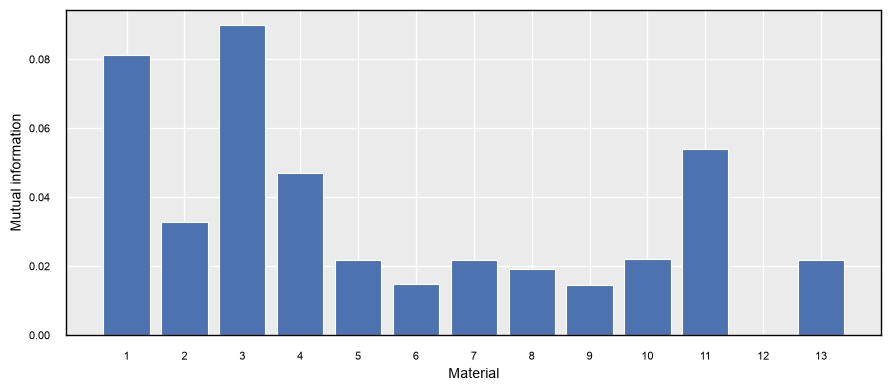

In [31]:
fig, ax = plt.subplots(figsize=(9, 4))

ax.bar(
    input_material_dependence["Material"],
    input_material_dependence["Mutual_Information"]
)

ax.set_xlabel("Material")
ax.set_ylabel("Mutual information")

ax.set_ylim(
    bottom=0
)

fig.tight_layout()

fig.savefig(
    FIGURE_DIR / "input_material_mutual_information_r.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()